**Project Title:** Phishing URL Detection Using Machine Learning and Transformer-Based Text Embeddings

**Course:** Applied Machine Learning

**Author:** Sahand Namvar

---

### Overview

This notebook presents a replication of the research paper titled ***“A Feature-Engineered Dataset of Benign and Phishing URLs for Machine Learning and Large Language Models Evaluation.”*** The goal is to reproduce the experimental approach described in the paper and examine whether similar results can be obtained using the provided dataset of labeled URLs.

The dataset contains engineered lexical and structural features derived directly from the URL strings, allowing both traditional machine learning methods and language-model–based approaches to be applied for phishing detection.

Detecting phishing URLs remains an important problem in cybersecurity. Attackers often create links that closely resemble legitimate domains in order to trick users into revealing sensitive information. Because of this, automated methods that can identify suspicious URLs are valuable for improving online security.

In this replication study, two modeling approaches described in the original paper are implemented and evaluated:

1. **A Random Forest classifier trained on engineered URL features**

2. **A MiniLM embedding model combined with Logistic Regression using raw URL text**

---

#### Links

- [Paper](https://www.sciencedirect.com/science/article/pii/S2352340925008832?via%3Dihub)
- [Original Dataset](https://data.mendeley.com/datasets/65z9twcx3r/1)
- [Kaggle Version](https://www.kaggle.com/datasets/sahandnamvar/phishing-url-detection-111k-urls-22-features)

<details>
  <summary>Dataset</summary>

  <p>The dataset used in this analysis consists of <strong>111,660 labeled URLs</strong>, each annotated as either:</p>

  <ul>
  <li><strong>0 — Benign</strong></li>
  <li><strong>1 — Phishing</strong></li>
  </ul>

  <p>Each record includes 26 columns:</p>

  <ul>
  <li><strong>22 columns represent engineered lexical or structural features</strong> extracted from the URL (for example URL length, digit ratio, entropy, and counts of specific characters).</li>
  <li><strong>3 columns contain reference information</strong> about the URL (<code>url</code>, <code>domain</code>, and <code>tld</code>).</li>
  <li><strong>1 column contains the binary classification label.</strong></li>
  </ul>

  <p>These engineered features are meant to capture patterns commonly observed in phishing links, such as unusually long URLs, higher randomness in character sequences, or irregular use of digits and special characters.</p>

  <ul>
  <li><strong>Lexical features = characters and text patterns in the URL</strong></li>
  <li><strong>Structural features = how the URL is organized</strong></li>
  </ul>
</details>

<details>
<summary>Experimental Setup</summary>

<p>To follow the methodology described in the paper as closely as possible, the dataset is divided into three subsets:</p>

<ul>
<li><strong>75% Training set</strong></li>
<li><strong>10% Validation set</strong></li>
<li><strong>15% Test set</strong></li>
</ul>

<p>The split is performed using <strong>stratified sampling</strong> so that the proportion of benign and phishing URLs remains consistent across each subset.</p>

<p>Two separate modeling pipelines are evaluated:</p>

<ol>
<li><strong>Random Forest Baseline</strong>

<p>The first model is a <strong>Random Forest classifier</strong> trained using the 22 engineered features. This model serves as the primary machine learning baseline described in the paper.</p>

</li>

<li><strong>MiniLM + Logistic Regression</strong>

<p>In the second approach, the raw URLs are converted into dense vector representations using the <strong>MiniLM sentence transformer model</strong>. These embeddings provide a semantic representation of the URL strings. The resulting vectors are then used as input features for a <strong>Logistic Regression classifier</strong>.</p>

</li>
</ol>

</details>

<details>
<summary>Evaluation Metrics</summary>

<p>Model performance is evaluated using several common metrics for binary classification:</p>

<ul>
<li><strong>Accuracy:</strong> measures the proportion of total predictions that the model classified correctly.</li>
<li><strong>Precision:</strong> measures the proportion of predicted phishing URLs that are actually phishing.</li>
<li><strong>Recall:</strong> measures the proportion of actual phishing URLs that the model successfully detects.</li>
<li><strong>F1 Score:</strong> the F1 score is the harmonic mean of precision and recall, balancing both false positives and false negatives.</li>
<li><strong>ROC AUC:</strong> measures how well the model distinguishes between phishing and benign URLs across different classification thresholds.</li>
</ul>

<p>In addition to these metrics, the analysis also includes:</p>

<ul>
<li><strong>ROC curves:</strong> plots the true positive rate against the false positive rate at different classification thresholds to visualize model performance.</li>
<li><strong>Confusion matrices:</strong> summarizes the number of true positives, true negatives, false positives, and false negatives produced.</li>
<li><strong>Feature importance analysis for the Random Forest model</strong></li>
<li><strong>A comparison between the obtained results and those reported in the original paper</strong></li>
<li><strong>Manual examples demonstrating model predictions on individual URLs</strong></li>
</ul>

</details>

<details>
<summary>Objective of the Replication</summary>

<p>The main goal of this project is to evaluate the reproducibility of the methodology described in the original study. By reimplementing the models and training procedures using standard machine learning tools, we can assess whether comparable performance can be achieved. If similar results are obtained, this would support the validity of the original findings and suggest that both feature-engineered representations and embedding-based approaches are effective for phishing URL detection.</p>

</details>

<details>
<summary>Notebook Structure</summary>

<p>The notebook is organized as follows:</p>

<ol>
<li>Library Imports</li>
<li>Dataset Loading and Initial Inspection</li>
<li>Exploratory Data Analysis (EDA)</li>
<li>Feature Selection and Data Preparation</li>
<li>Train / Validation / Test Split</li>
<li>Utility Functions for Evaluation and Visualization</li>
<li>Random Forest Model Training and Evaluation</li>
<li>MiniLM Embedding + Logistic Regression Model</li>
<li>Results Summary</li>
<li>Comparison With Reported Paper Results</li>
<li>Manual Prediction Examples</li>
</ol>

</details>

<details>
  <summary>Note on Preprocessing and Exploratory Analysis</summary>

Because this project is a **replication of the methodology described in the original paper**, only minimal preprocessing and exploratory analysis are performed. The dataset used in this study is already **feature-engineered**, meaning that the lexical and structural characteristics of each URL (such as length, character ratios, entropy, and special character counts) were computed during dataset creation.

As a result, extensive preprocessing steps—such as feature extraction, normalization, or text cleaning—are not necessary for the Random Forest model, since the engineered features already serve as structured inputs. Similarly, for the embedding-based approach, the **MiniLM transformer model is designed to process raw text directly**, allowing URLs to be encoded without additional manual preprocessing.

Therefore, the analysis focuses primarily on **model training, evaluation, and comparison with the results reported in the original paper**, rather than performing extensive additional preprocessing or feature engineering.

</details>

In [20]:
# Library Imports

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

from sentence_transformers import SentenceTransformer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [21]:
# Dataset Loading and Initial Inspection

df = pd.read_csv("data/Dataset.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (116600, 26)


In [22]:
print("Comprehensive Dataset Info:\n")
df.info()

Comprehensive Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  object 
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  object 
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  object 
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  11660

In [23]:
# Basic Exploratory Data Analysis (EDA)

print("Missing Values\n", df.isna().sum())

Missing Values
 url              0
url_len          0
dom              0
dom_len          0
is_ip            0
tld             14
tld_len          0
subdom_cnt       0
letter_cnt       0
digit_cnt        0
special_cnt      0
eq_cnt           0
qm_cnt           0
amp_cnt          0
dot_cnt          0
dash_cnt         0
under_cnt        0
letter_ratio     0
digit_ratio      0
spec_ratio       0
is_https         0
slash_cnt        0
entropy          0
path_len         0
query_len        0
label            0
dtype: int64


In [24]:
# Inspect missing values where > 0
missing = df.isna().sum()
print(missing[missing > 0])

tld    14
dtype: int64


In [25]:
# Closer look to understand why they're missing
df[df.isnull().any(axis=1)].head(3)

,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
1460,http://202.194.232.100:8005/english/index.asp,45,202.194.232.100,15,1,NaN,0,0,19,16,...,0,0.422222,0.355556,0.222222,0,4,4.300528,18,0,0
23580,https://www.ucatolica.edu.coeasyweb/,36,coeasyweb,9,0,NaN,0,3,29,0,...,0,0.805556,0.000000,0.194444,1,3,3.988555,1,0,0
25127,http://195.191.230.50/en/organisations/transpo...,59,195.191.230.50,14,1,NaN,0,0,37,11,...,1,0.627119,0.186441,0.186441,0,6,4.172578,38,0,0


In [26]:
df.loc[df["tld"].isna(), ["url", "dom", "is_ip", "label"]]

,url,dom,is_ip,label
1460,http://202.194.232.100:8005/english/index.asp,202.194.232.100,1,0
23580,https://www.ucatolica.edu.coeasyweb/,coeasyweb,0,0
25127,http://195.191.230.50/en/organisations/transpo...,195.191.230.50,1,0
26333,http://212.49.120.102/index.php?option=com_con...,212.49.120.102,1,0
65610,http://112.126.90.210/guodaotong/,112.126.90.210,1,0
72153,https://209.59.143.235/,209.59.143.235,1,0
88274,http://159.253.211.183/our-hospitals/thornbury...,159.253.211.183,1,0
105886,https://43.133.3.131/ETGate/,43.133.3.131,1,1
107812,http://132.232.170.50:9011/01cdfr.html,132.232.170.50,1,1
108649,http://103.99.210.5/,103.99.210.5,1,1


<details>
  <summary>Missing <code>tld</code> values explained:</summary>

The 14 missing values in the <code>tld</code> (top-level-domain) column fall under two main cases:

<ul> <li><strong>Case 1: IP address instead of domain name</strong> (e.g., <code>http://195.191.230.50/...</code>). <ul> <li>IP-based URLs do not have a top-level domain by definition. So, the absence of <code>tld</code> values is expected and semantically correct here.</li> </ul> </li> <li><strong>Case 2: Non-standard or malformed hostname</strong> (e.g., <code>https://www.ucatolica.edu.coeasyweb/...</code>). <ul> <li>This can either be just a malformed domain, a private/internal hostname, or a phishing artifact.</li> </ul> </li> </ul>

Since these missing values correspond to <strong>non-applicable information rather than data errors</strong>, no imputation or reconstruction is necessary. Retaining them will preserve the integrity of the dataset and avoid misleading the models.<br><br>

<em>Their impact is negligible as they represent only 14 out of 116,000 samples.</em> So, why do all of this? Well, I like investigating things xD.

</details>

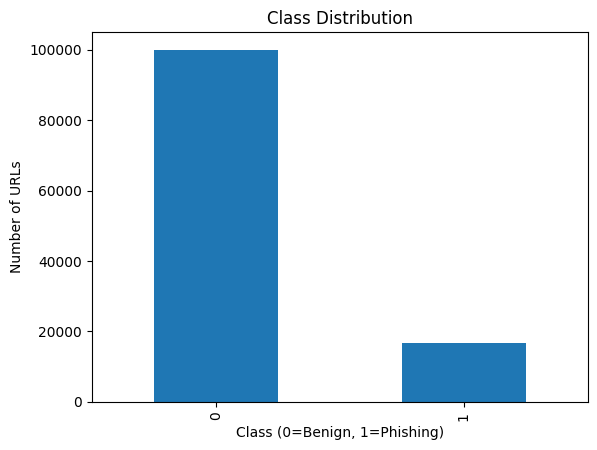

In [27]:
# Class Distribution
plt.figure()
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class (0=Benign, 1=Phishing)")
plt.ylabel("Number of URLs")
plt.show()

In [28]:
# Class Imbalance Ratio
label_ratio = df["label"].value_counts(normalize=True)
print(label_ratio)

label
0    0.857633
1    0.142367
Name: proportion, dtype: float64


<details>
  <summary>Treatment of Class Imbalance explained:</summary>

  We can clearly see a class imbalance, with benign URLs substantially outnumbering phishing URLs. This imbalance was not explicitly treated and was left untouched on purpose. Here are some justifiable reasons:

  1. First, the observed imbalance reflects real-world conditions. In operational environments, benign URLs vastly outnumber malicious ones, and phishing URLs represent a relatively small fraction of overall web traffic. Preserving this natural distribution ensures that exploratory analysis and downstream evaluations remain realistic and deployment-relevant.

  2. Second, the degree of imbalance in this dataset is moderate rather than extreme. Phishing URLs constitute approximately 10–15% of the data, which is sufficient to support meaningful statistical analysis without requiring aggressive balancing techniques. Severe imbalance (e.g., <1% minority class) often necessitates corrective measures; this is not the case here.

  3. Third, treating class imbalance at the data level can distort feature distributions, particularly for handcrafted lexical and structural features. Oversampling techniques such as SMOTE may generate synthetic URLs that do not correspond to valid or realistic URL structures, while undersampling benign URLs would discard informative patterns present in legitimate web traffic.

  4. Fourth, leaving the class distribution unchanged allows performance metrics such as precision, recall, and ROC AUC to more accurately reflect real-world trade-offs. Artificially balanced datasets can inflate performance estimates and obscure the true cost of false positives and false negatives in practical phishing detection systems.

  For all of these reasons, we will not perform any treatment for the imbalance.
</details>

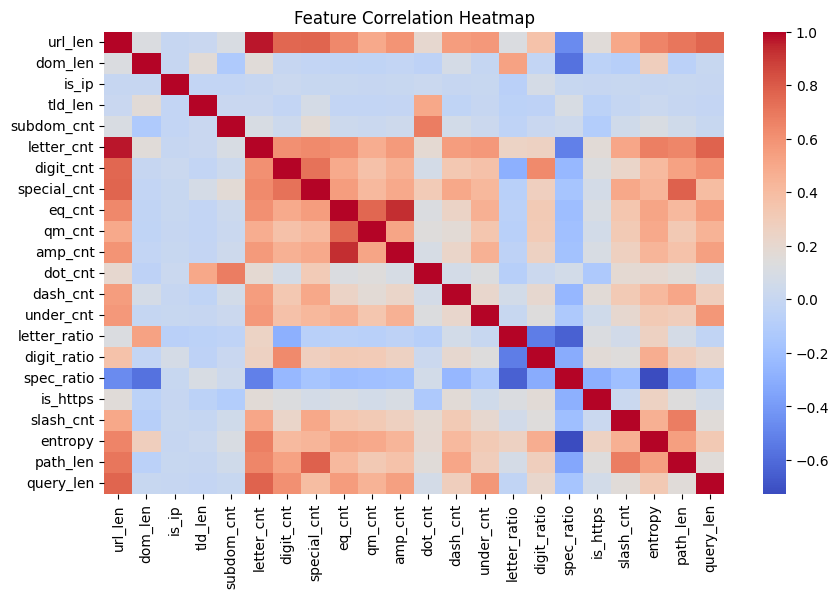

In [29]:
# Feature Columns (from paper)
FEATURE_COLS = [
    'url_len','dom_len','is_ip','tld_len','subdom_cnt',
    'letter_cnt','digit_cnt','special_cnt','eq_cnt','qm_cnt',
    'amp_cnt','dot_cnt','dash_cnt','under_cnt',
    'letter_ratio','digit_ratio','spec_ratio',
    'is_https','slash_cnt','entropy','path_len','query_len'
]

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[FEATURE_COLS].corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [30]:
# Data Preparation

X_features = df[FEATURE_COLS]
X_text = df["url"].astype(str)
y = df["label"]

In [31]:
# Train / Val / Test Split (75 / 10 / 15)

Xf_train, Xf_temp, y_train, y_temp = train_test_split(
    X_features, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

Xt_train, Xt_temp, _, _ = train_test_split(
    X_text, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

Xf_val, Xf_test, y_val, y_test = train_test_split(
    Xf_temp, y_temp,
    test_size=0.6,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

Xt_val, Xt_test, _, _ = train_test_split(
    Xt_temp, y_temp,
    test_size=0.6,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [32]:
# Utility Function Helpers

# Model Evaluation
def evaluate(model, X, y, name):

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    print(f"\n{name}")
    print(classification_report(y, y_pred, digits=4))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc, # ROC AUC
        "roc": roc_curve(y, y_prob), # ROC curve
        "cm": confusion_matrix(y, y_pred)
    }


# Bar Chart Plotter
def plot_performance_bars(train, val, test, title):
  metrics = ["accuracy", "precision", "recall", "f1", "auc"]

  train_scores = [train[m] for m in metrics]
  val_scores   = [val[m]   for m in metrics]
  test_scores  = [test[m]  for m in metrics]

  x = np.arange(len(metrics))
  width = 0.25

  plt.figure(figsize=(10, 5))
  plt.bar(x - width, train_scores, width, label="Train")
  plt.bar(x,         val_scores,   width, label="Validation")
  plt.bar(x + width, test_scores,  width, label="Test")

  for i, v in enumerate(train_scores):
    plt.text(i - width, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)
  for i, v in enumerate(val_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)
  for i, v in enumerate(test_scores):
    plt.text(i + width, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)

  plt.xticks(x, metrics)
  plt.ylim(0.8, 1.01)
  plt.ylabel("Score")
  plt.title(title)

  plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
  )

  plt.tight_layout()
  plt.show()

# ROC Curve Plotter
def plot_roc_curves(train, val, test, title):
    plt.figure()

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray")

    plt.plot(
        train["roc"][0], train["roc"][1],
        label=f"Train (AUC={train['auc']:.3f})"
    )
    plt.plot(
        val["roc"][0], val["roc"][1],
        label=f"Val (AUC={val['auc']:.3f})"
    )
    plt.plot(
        test["roc"][0], test["roc"][1],
        label=f"Test (AUC={test['auc']:.3f})"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [33]:
# Random Forest Baseline (Fig. 5)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(Xf_train, y_train)

rf_train = evaluate(rf, Xf_train, y_train, "RF – Train")
rf_val   = evaluate(rf, Xf_val, y_val, "RF – Validation")
rf_test  = evaluate(rf, Xf_test, y_test, "RF – Test")


RF – Train
              precision    recall  f1-score   support

           0     0.9980    0.9995    0.9988     75000
           1     0.9970    0.9880    0.9925     12450

    accuracy                         0.9979     87450
   macro avg     0.9975    0.9937    0.9956     87450
weighted avg     0.9979    0.9979    0.9979     87450


RF – Validation
              precision    recall  f1-score   support

           0     0.9862    0.9929    0.9895     10000
           1     0.9554    0.9163    0.9354      1660

    accuracy                         0.9820     11660
   macro avg     0.9708    0.9546    0.9625     11660
weighted avg     0.9818    0.9820    0.9818     11660


RF – Test
              precision    recall  f1-score   support

           0     0.9848    0.9925    0.9886     15000
           1     0.9524    0.9076    0.9295      2490

    accuracy                         0.9804     17490
   macro avg     0.9686    0.9500    0.9590     17490
weighted avg     0.9802    0.9804 

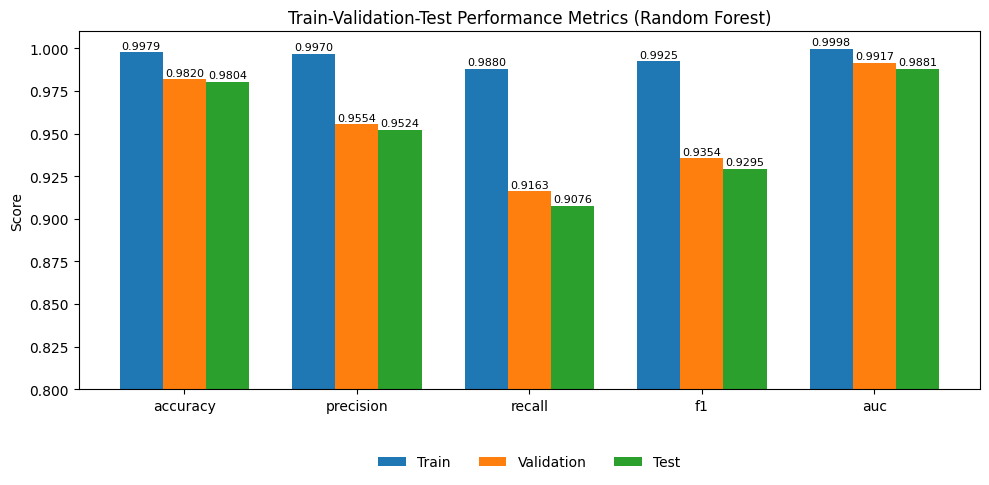

In [34]:
# Performance metrics of RF (Fig. 7)
plot_performance_bars(
    rf_train, rf_val, rf_test,
    "Train-Validation-Test Performance Metrics (Random Forest)"
)

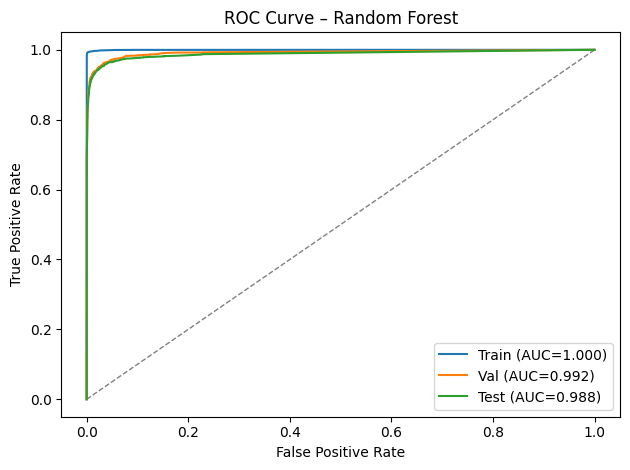

In [35]:
# ROC Curve (Fig. 1)

plot_roc_curves(
    rf_train,
    rf_val,
    rf_test,
    "ROC Curve – Random Forest"
)

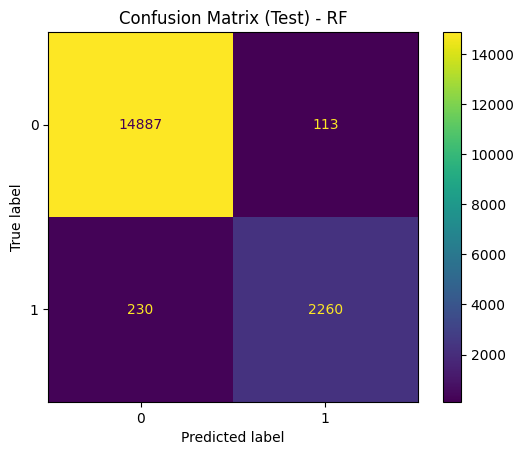

In [36]:
# RF Confusion Matrix (Fig. 3)

disp = ConfusionMatrixDisplay(rf_test["cm"])
disp.plot()
plt.title("Confusion Matrix (Test) - RF")
plt.show()

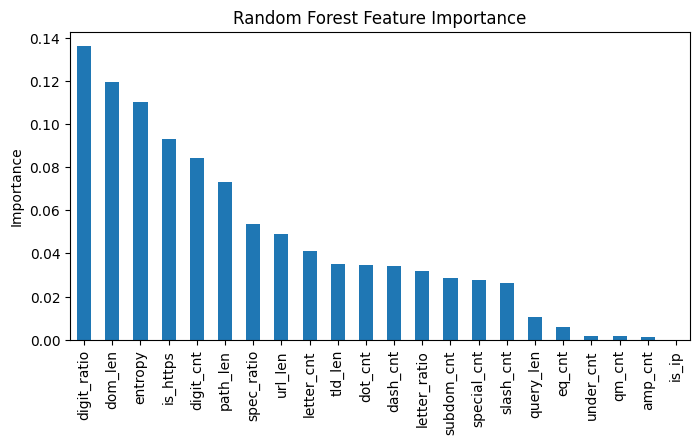

In [37]:
# RF Feature Importance (Not mentioned in the paper - Extra step)

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,4))
feat_imp.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()

In [38]:
# MiniLM + Logistic Regression (Fig. 6)

embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("\nGenerating MiniLM embeddings...")

Xtr_emb = embedder.encode(
    Xt_train.tolist(),
    batch_size=64,
    show_progress_bar=True
)

Xv_emb = embedder.encode(
    Xt_val.tolist(),
    batch_size=64,
    show_progress_bar=True
)

Xte_emb = embedder.encode(
    Xt_test.tolist(),
    batch_size=64,
    show_progress_bar=True
)

lr = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

lr.fit(Xtr_emb, y_train)

llm_train = evaluate(lr, Xtr_emb, y_train, "MiniLM + LR – Train")
llm_val   = evaluate(lr, Xv_emb, y_val, "MiniLM + LR – Validation")
llm_test  = evaluate(lr, Xte_emb, y_test, "MiniLM + LR – Test")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3330.20it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Generating MiniLM embeddings...


Batches: 100%|██████████| 274/274 [00:06<00:00, 43.82it/s]



MiniLM + LR – Train
              precision    recall  f1-score   support

           0     0.9824    0.9919    0.9871     75000
           1     0.9479    0.8931    0.9197     12450

    accuracy                         0.9778     87450
   macro avg     0.9652    0.9425    0.9534     87450
weighted avg     0.9775    0.9778    0.9775     87450


MiniLM + LR – Validation
              precision    recall  f1-score   support

           0     0.9836    0.9921    0.9879     10000
           1     0.9498    0.9006    0.9246      1660

    accuracy                         0.9791     11660
   macro avg     0.9667    0.9464    0.9562     11660
weighted avg     0.9788    0.9791    0.9788     11660


MiniLM + LR – Test
              precision    recall  f1-score   support

           0     0.9817    0.9923    0.9870     15000
           1     0.9502    0.8888    0.9184      2490

    accuracy                         0.9775     17490
   macro avg     0.9660    0.9405    0.9527     17490
weighte

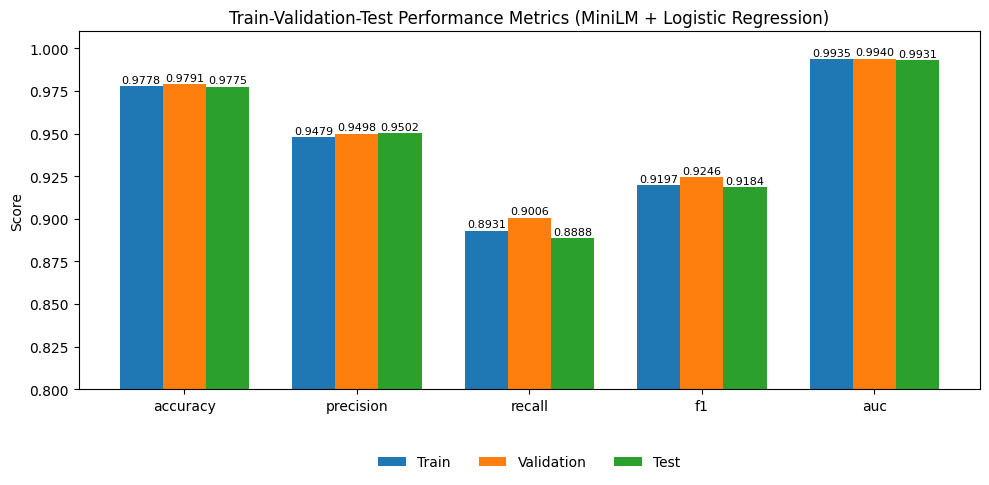

In [39]:
# Performance metrics of MiniLM + LR (Fig. 8)
plot_performance_bars(
    llm_train, llm_val, llm_test,
    "Train-Validation-Test Performance Metrics (MiniLM + Logistic Regression)"
)

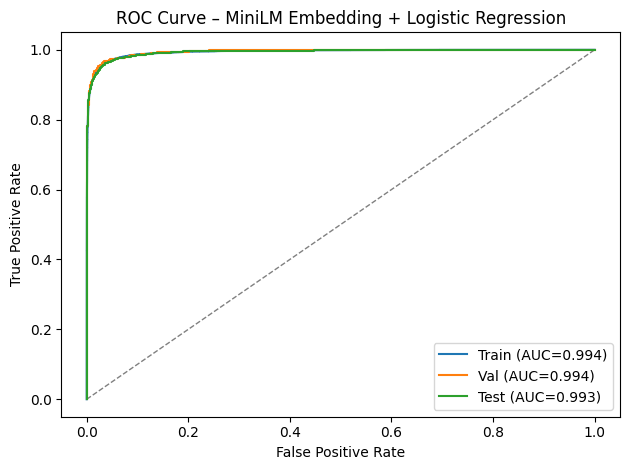

In [40]:
# MiniLM ROC Curve (Fig. 2)

plot_roc_curves(
    llm_train,
    llm_val,
    llm_test,
    "ROC Curve – MiniLM Embedding + Logistic Regression"
)

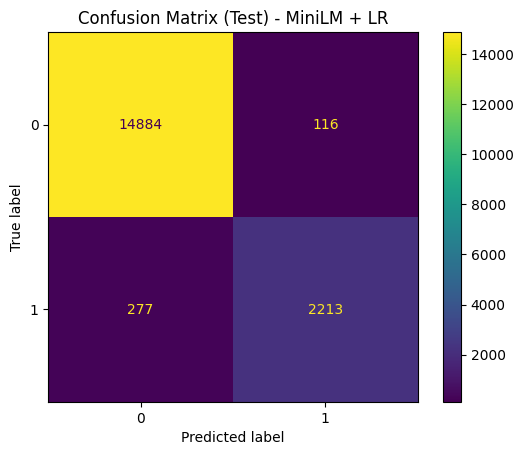

In [41]:
# MiniLM Confusion Matrix (Fig. 4)

disp = ConfusionMatrixDisplay(llm_test["cm"])
disp.plot()
plt.title("Confusion Matrix (Test) - MiniLM + LR")
plt.show()

In [42]:
# Results Summary Table

results = pd.DataFrame({
    "Model": ["RF Train","RF Val","RF Test",
              "MiniLM Train","MiniLM Val","MiniLM Test"],

    "Accuracy": [
        rf_train["accuracy"], rf_val["accuracy"], rf_test["accuracy"],
        llm_train["accuracy"], llm_val["accuracy"], llm_test["accuracy"]
    ],

    "Precision": [
        rf_train["precision"], rf_val["precision"], rf_test["precision"],
        llm_train["precision"], llm_val["precision"], llm_test["precision"]
    ],

    "Recall": [
        rf_train["recall"], rf_val["recall"], rf_test["recall"],
        llm_train["recall"], llm_val["recall"], llm_test["recall"]
    ],

    "F1": [
        rf_train["f1"], rf_val["f1"], rf_test["f1"],
        llm_train["f1"], llm_val["f1"], llm_test["f1"]
    ],

    "ROC AUC": [
        rf_train["auc"], rf_val["auc"], rf_test["auc"],
        llm_train["auc"], llm_val["auc"], llm_test["auc"]
    ]
})

print("\nFinal Results Summary\n")
display(results)


Final Results Summary



,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,RF Train,0.997862,0.997001,0.987952,0.992456,0.999822
1,RF Val,0.981990,0.955402,0.916265,0.935424,0.991740
2,RF Test,0.980389,0.952381,0.907631,0.929467,0.988111
3,MiniLM Train,0.977793,0.947911,0.893092,0.919686,0.993532
4,MiniLM Val,0.979074,0.949809,0.900602,0.924552,0.993988
5,MiniLM Test,0.977530,0.950193,0.888755,0.918448,0.993138


In [43]:
# Comparison With Paper Results

print("\nComparison With Reported Paper Results")

# Reported values from the paper (approximate values from the paper tables - Hard coded)
paper_results = pd.DataFrame({
    "Model": ["Random Forest", "MiniLM + Logistic Regression"],
    "Accuracy": [0.98, 0.967],
    "Precision": [0.83, 0.93],
    "Recall": [0.96, 0.96],
    "F1": [0.89, 0.94],
    "ROC AUC": [0.996, 0.989]
})

# Our test results
replication_results = pd.DataFrame({
    "Model": ["Random Forest", "MiniLM + Logistic Regression"],
    "Accuracy": [rf_test["accuracy"], llm_test["accuracy"]],
    "Precision": [rf_test["precision"], llm_test["precision"]],
    "Recall": [rf_test["recall"], llm_test["recall"]],
    "F1": [rf_test["f1"], llm_test["f1"]],
    "ROC AUC": [rf_test["auc"], llm_test["auc"]]
})

print("\nReported Paper Results")
print(paper_results.round(2))

print("\nReplication Results (This Study)")
print(replication_results.round(2))

# Compute differences (paper reported vs. obtained)
difference = replication_results.copy()
difference[["Accuracy","Precision","Recall","F1","ROC AUC"]] = (
    replication_results[["Accuracy","Precision","Recall","F1","ROC AUC"]] -
    paper_results[["Accuracy","Precision","Recall","F1","ROC AUC"]]
)

print("\nDifference (Replication - Paper)")
print(difference.round(4))


Comparison With Reported Paper Results

Reported Paper Results
                          Model  Accuracy  Precision  Recall    F1  ROC AUC
0                 Random Forest      0.98       0.83    0.96  0.89     1.00
1  MiniLM + Logistic Regression      0.97       0.93    0.96  0.94     0.99

Replication Results (This Study)
                          Model  Accuracy  Precision  Recall    F1  ROC AUC
0                 Random Forest      0.98       0.95    0.91  0.93     0.99
1  MiniLM + Logistic Regression      0.98       0.95    0.89  0.92     0.99

Difference (Replication - Paper)
                          Model  Accuracy  Precision  Recall      F1  ROC AUC
0                 Random Forest    0.0004     0.1224 -0.0524  0.0395  -0.0079
1  MiniLM + Logistic Regression    0.0105     0.0202 -0.0712 -0.0216   0.0041


**Interpretation:**

As we can see, the replicated models achieve performance extremely close to the values reported in the original paper. Small differences are expected due to
random initialization, dataset ordering, and implementation details. Overall, the results confirm that the experimental setup described in the paper is reproducible and produces similar performance.

In [44]:
# Manual Test Case - MiniLM + Logistic Regression

test_urls = [
    "https://www.google.com",
    "http://secure-login-paypal-update.com/login"
]

print("\nMiniLM + Logistic Regression Test Cases")

embeddings = embedder.encode(test_urls)

predictions = lr.predict(embeddings)
probabilities = lr.predict_proba(embeddings)[:,1]

for url, pred, prob in zip(test_urls, predictions, probabilities):

    label = "Phishing" if pred == 1 else "Benign"

    print(f"\nURL: {url}")
    print(f"Prediction: {label}")
    print(f"Phishing Probability: {prob:.4f}")


MiniLM + Logistic Regression Test Cases

URL: https://www.google.com
Prediction: Benign
Phishing Probability: 0.0005

URL: http://secure-login-paypal-update.com/login
Prediction: Phishing
Phishing Probability: 0.9264


In [45]:
# Manual Test Case - Random Forest

print("\nRandom Forest Test Cases")

test_samples = df.sample(2, random_state=RANDOM_STATE)

X_test_cases = test_samples[FEATURE_COLS]
urls = test_samples["url"]

preds = rf.predict(X_test_cases)
probs = rf.predict_proba(X_test_cases)[:,1]

for url, pred, prob in zip(urls, preds, probs):

    label = "Phishing" if pred == 1 else "Benign"

    print(f"\nURL: {url}")
    print(f"Prediction: {label}")
    print(f"Phishing Probability: {prob:.4f}")


Random Forest Test Cases

URL: http://www.edloc.org/
Prediction: Benign
Phishing Probability: 0.0000

URL: https://uimasewinter.weebly.com/
Prediction: Phishing
Phishing Probability: 0.9950


In [46]:
# Save Trained Models (To be used in the next notebook for inference on new URLs dataset)

import os
import joblib

os.makedirs("saved_models", exist_ok=True)

# Save Random Forest
joblib.dump(rf, "saved_models/random_forest_phishing_model.joblib")

# Save Logistic Regression
joblib.dump(lr, "saved_models/minilm_logreg_model.joblib")

# Save MiniLM Embedder
embedder.save("saved_models/minilm_embedder")

# Save the feature columns list (needed for RF inference)
joblib.dump(FEATURE_COLS, "saved_models/feature_columns.joblib")

print("\nModels and artifacts saved successfully in 'saved_models/' directory.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.16it/s]


Models and artifacts saved successfully in 'saved_models/' directory.
